In [134]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

In [135]:
def backtracking(fun,x,fun_xk,grad_xk,alpha,c_1,rho,inter_b):
    alpha_i=np.copy(alpha)
    for i in range(inter_b):
        fun_alphai=fun(x-alpha_i*grad_xk)
        cond=fun_alphai<=fun_xk-c_1*alpha_i*np.dot(grad_xk,grad_xk)
        if cond:
            return  alpha_i, i
        alpha_i*=rho
    return  max(alpha_i,1e-8), i

In [136]:
def Projected_Gradient_Descent(f,g,proye,limi,tao,inter,x,alpha,c,rho_ba,inter_ba,guardar):
    v_x=[]
    v_g=[]
    v_f=[]
    x_i=x
    f_i=f(x)
    g_i=g(x_i)
    res=0
    alpha_g=np.copy(alpha)
    for i in range(inter):
        alpha=np.copy(alpha_g)
        n_g_i=np.linalg.norm(g_i)
        if guardar:
            v_x.append(np.copy(x_i))
            v_g.append(np.copy(g_i))
            v_f.append(np.copy(f_i))
        if n_g_i<tao:
            res=1
            break
        alpha,j=backtracking(f,x_i,f_i,g_i,alpha,c,rho_ba,inter_ba)
        x_ip1=x_i-alpha*g_i
        x_ip1=proye(x_ip1,limi)
        x_i=x_ip1
        g_i=g(x_i)
        f_i=f(x_i)
    if guardar:
        return  x_i,g_i,f_i,i,np.array(v_x),np.array(v_g),np.array(v_f),res
    else:
        return x_i,g_i,f_i,i,res

In [137]:
def proyec_radial(x,R):
    X=np.copy(x)
    no_x=np.linalg.norm(X)
    #print("R",no_x)
    if no_x>R:
        #print("mayor")
        X=R*X/no_x
    return X

In [138]:
def proyec_caja(x,para):
    X=np.copy(x)
    con_X_ma=np.array([X,para[:,0]])
    con_X_ma=con_X_ma.T
    maximos=np.max(con_X_ma,axis=1)
    con_X_min=np.array([maximos,para[:,1]])
    con_X_min=con_X_min.T
    minimos=np.min(con_X_min,axis=1)
    return minimos

In [139]:
def fun_i(x):
    return x[0]**2+x[1]**2+4*x[0]-6*x[1]

In [140]:
def grad_fun_i(x):
    gra=np.array([2*x[0]+4,2*x[1]-6])
    return gra


In [141]:
def fun_ii(x):
    f=-x[0]**2-4*x[1]**2+2*x[0]*x[1]+4*x[0]+2*x[1]-24
    return -f

In [142]:
def grad_fun_ii(x):
    gra=np.array([-2*x[0]+2*x[1]+4,-8*x[1]+2*x[0]+2])
    return -gra

time: 0.0261991024017334
f(x_ini): 24
iterracciones: 42
res: 1
norma de g_k 0.00093116953226879
[[4.         4.        ]
 [2.37279615 3.22022335]
 [1.49823692 3.17617868]]
[[-1.99927344  3.00003659]
 [-1.99941876  3.00002927]
 [-1.999535    3.00002342]]
f(x_k): -12.999999783230825


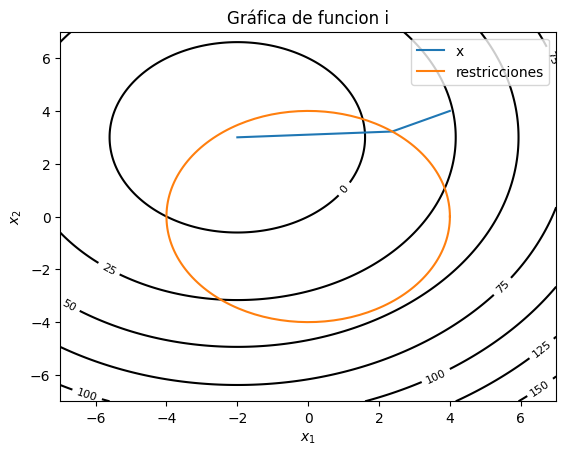

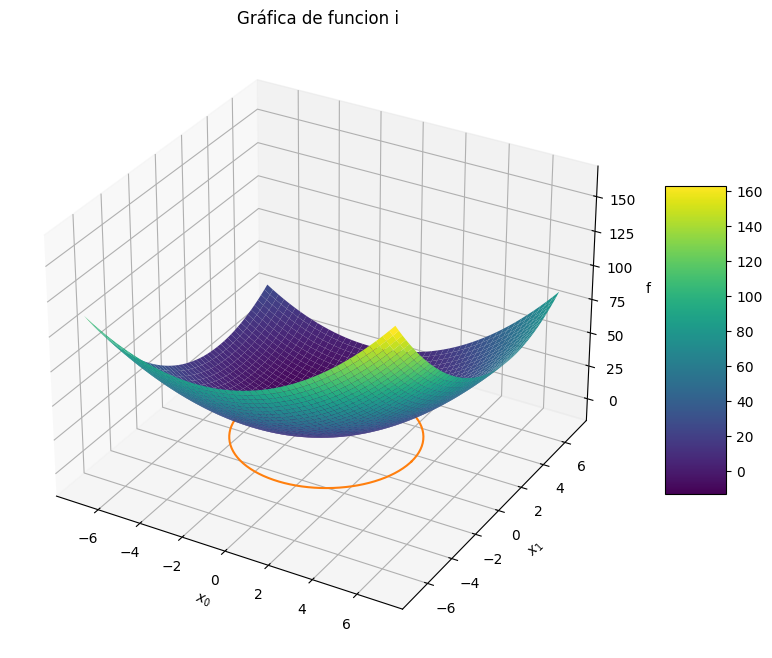

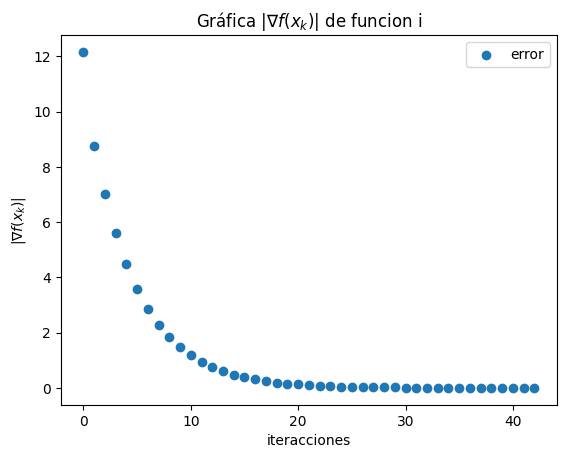

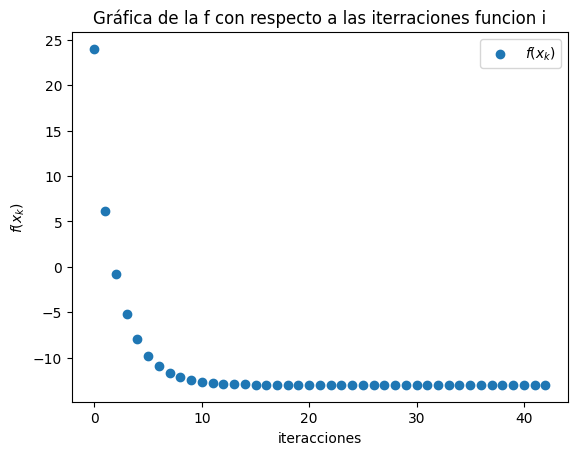

In [143]:
x_0=np.array([4,4])    
tm_0=tm.time()
nom_fu="funcion i"
x_k,g_k,f_k,i,v_x,v_g,v_f,res=Projected_Gradient_Descent(f=fun_i,g=grad_fun_i,proye=proyec_radial,limi=4,tao=10**(-3),inter=100,x=x_0,alpha=0.1,c=0.1,rho_ba=0.6,inter_ba=100,guardar=True)
tm_1=tm.time()
print("time:",tm_1-tm_0)
print("f(x_ini):",fun_i(x_0))
print("iterracciones:",i)
print("res:",res)
print("norma de g_k",np.linalg.norm(g_k))
if len(v_x)<=6:
    print(v_x)
else:
    print(v_x[:3])
    print(v_x[-3:])
    print("f(x_k):",f_k)


x_0=np.linspace(-7,7,500)
x_1=np.linspace(-7,7,500)
x_0,x_1=np.meshgrid(x_0,x_1)
fu_g=fun_i(np.array([x_0,x_1]))
angu=np.linspace(0,2*np.pi,200)
plt.figure()
contours=plt.contour(x_0, x_1, fu_g, levels=7, colors='black')  # Líneas de contorno
plt.clabel(contours, inline=True, fontsize=8)
plt.plot(v_x[:,0],v_x[:,1],label="x")
plt.plot(4*np.cos(angu),4*np.sin(angu),label="restricciones")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Gráfica de "+nom_fu)
plt.legend()
plt.savefig("pro_2_1_"+nom_fu+".pdf")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_0, x_1, fu_g, cmap='viridis')
plt.plot(4*np.cos(angu),4*np.sin(angu),label="restricciones")
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.plot(v_x[:,0],v_x[:,1],v_f,linewidth=5,label="punto evaluacion")
# Etiquetas
ax.set_xlabel(r'$x_0$')
ax.set_ylabel(r'$x_1$')
ax.set_zlabel(r'f')
ax.set_title('Gráfica de '+nom_fu)
plt.savefig("pro_2_2_"+nom_fu+".pdf")
plt.show()

plt.figure()
plt.scatter(np.arange(len(v_g)),np.linalg.norm(v_g,axis=1),label="error")
plt.xlabel("iteracciones")
plt.ylabel(r"$\|\nabla f(x_k)\|$")
plt.title(r"Gráfica $\|\nabla f(x_k)\|$ de "+nom_fu)
plt.legend()
plt.savefig("pro_2_3_"+nom_fu+".pdf")

plt.figure()
plt.scatter(np.arange(len(v_f)),v_f,label=r"$f(x_k)$")
plt.xlabel("iteracciones")
plt.ylabel(r"$f(x_k)$")
plt.title(r"Gráfica de la f con respecto a las iterraciones "+nom_fu)
plt.legend()
plt.savefig("pro_2_4_"+nom_fu+".pdf")

time: 0.008080720901489258
f(x_ini): 48
iterracciones: 51
res: 1
norma de g_k 0.0009088449026652582
[[4.   4.  ]
 [4.   1.8 ]
 [3.96 1.36]]
[[3.00084233 1.00025504]
 [3.00072487 1.00021947]
 [3.00062379 1.00018887]]
f(x_k): 17.000000296174054


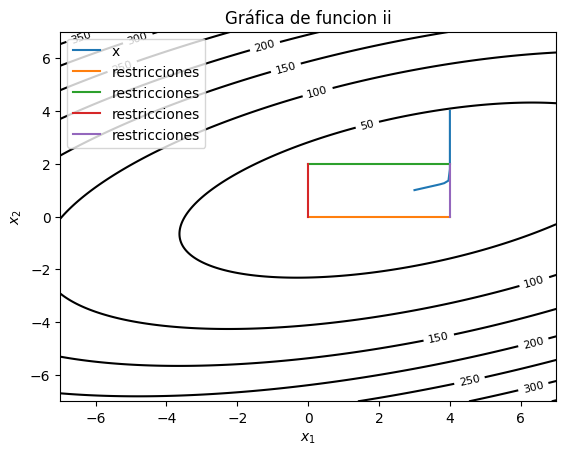

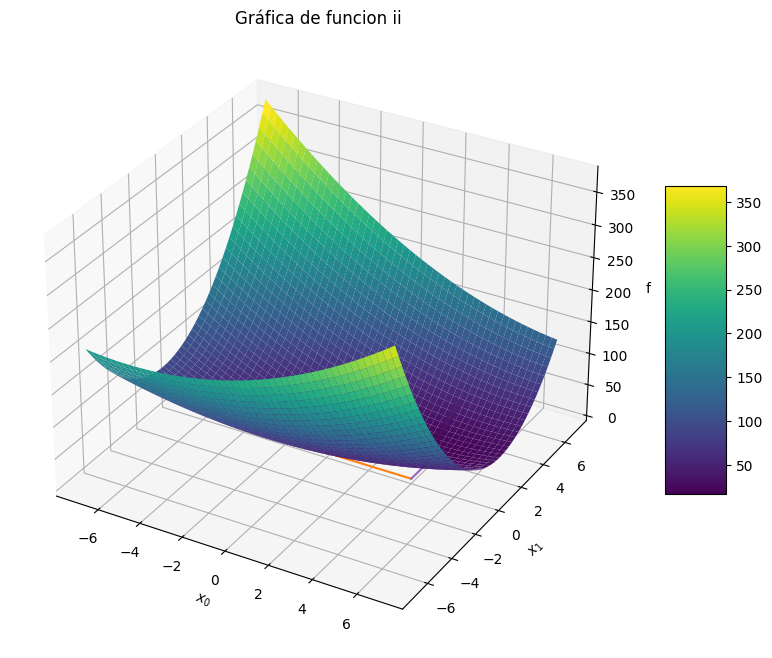

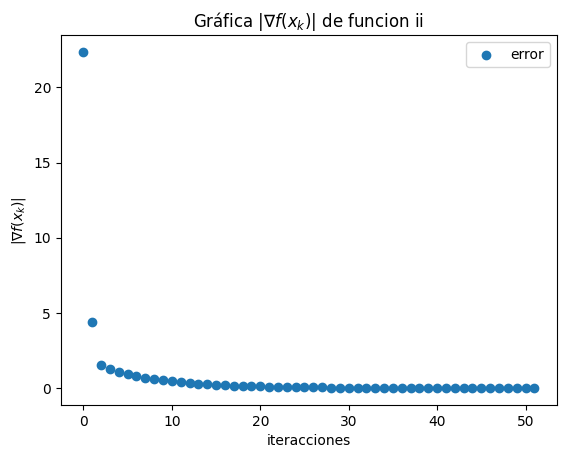

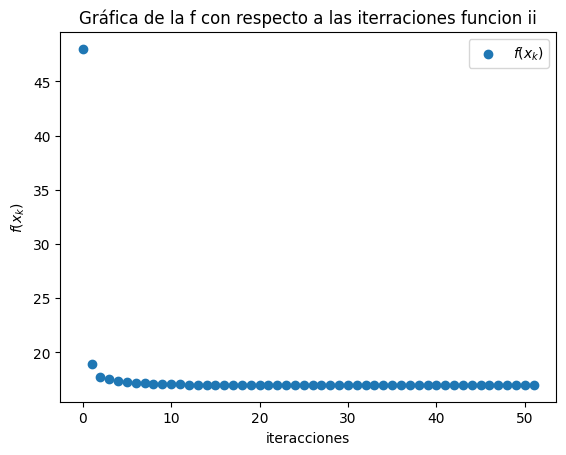

In [144]:
x_0=np.array([4,4])
limit=np.array([[0,4],[0,2]])
tm_0=tm.time()
nom_fu="funcion ii"
x_k,g_k,f_k,i,v_x,v_g,v_f,res=Projected_Gradient_Descent(f=fun_ii,g=grad_fun_ii,proye=proyec_caja,limi=limit,tao=10**(-3),inter=100,x=x_0,alpha=0.1,c=0.1,rho_ba=0.6,inter_ba=100,guardar=True)
tm_1=tm.time()
print("time:",tm_1-tm_0)
print("f(x_ini):",fun_ii(x_0))
print("iterracciones:",i)
print("res:",res)
print("norma de g_k",np.linalg.norm(g_k))
if len(v_x)<=6:
    print(v_x)
else:
    print(v_x[:3])
    print(v_x[-3:])
    print("f(x_k):",f_k)


x_0=np.linspace(-7,7,500)
x_1=np.linspace(-7,7,500)
x_0,x_1=np.meshgrid(x_0,x_1)
fu_g=fun_ii(np.array([x_0,x_1]))
x_1_l=np.linspace(0,4,200)
x_2_l=np.linspace(0,2,200)
plt.figure()
contours=plt.contour(x_0, x_1, fu_g, levels=7, colors='black')  # Líneas de contorno
plt.clabel(contours, inline=True, fontsize=8)
plt.plot(v_x[:,0],v_x[:,1],label="x")
plt.plot(x_1_l,x_2_l[0]*np.ones_like(x_1_l),label="restricciones")
plt.plot(x_1_l,x_2_l[-1]*np.ones_like(x_1_l),label="restricciones")
plt.plot(x_1_l[0]*np.ones_like(x_2_l),x_2_l,label="restricciones")
plt.plot(x_1_l[-1]*np.ones_like(x_2_l),x_2_l,label="restricciones")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Gráfica de "+nom_fu)
plt.legend()
plt.savefig("pro_2_1_"+nom_fu+".pdf")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_0, x_1, fu_g, cmap='viridis')
plt.plot(x_1_l,x_2_l[0]*np.ones_like(x_1_l),label="restricciones")
plt.plot(x_1_l,x_2_l[-1]*np.ones_like(x_1_l),label="restricciones")
plt.plot(x_1_l[0]*np.ones_like(x_2_l),x_2_l,label="restricciones")
plt.plot(x_1_l[-1]*np.ones_like(x_2_l),x_2_l,label="restricciones")
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.plot(v_x[:,0],v_x[:,1],v_f,linewidth=5,label="punto evaluacion")
# Etiquetas
ax.set_xlabel(r'$x_0$')
ax.set_ylabel(r'$x_1$')
ax.set_zlabel(r'f')
ax.set_title('Gráfica de '+nom_fu)
plt.savefig("pro_2_2_"+nom_fu+".pdf")
plt.show()

plt.figure()
plt.scatter(np.arange(len(v_g)),np.linalg.norm(v_g,axis=1),label="error")
plt.xlabel("iteracciones")
plt.ylabel(r"$\|\nabla f(x_k)\|$")
plt.title(r"Gráfica $\|\nabla f(x_k)\|$ de "+nom_fu)
plt.legend()
plt.savefig("pro_2_3_"+nom_fu+".pdf")

plt.figure()
plt.scatter(np.arange(len(v_f)),v_f,label=r"$f(x_k)$")
plt.xlabel("iteracciones")
plt.ylabel(r"$f(x_k)$")
plt.title(r"Gráfica de la f con respecto a las iterraciones "+nom_fu)
plt.legend()
plt.savefig("pro_2_4_"+nom_fu+".pdf")